In [ ]:

import matplotlib.pyplot as plt
import pandas as pd

from pathlib import Path



In [ ]:
from google.colab import files
uploaded = files.upload()


Saving cleanednox_newusd.csv to cleanednox_newusd (2).csv


In [ ]:

raw = pd.read_csv(list(uploaded.keys())[0])


In [ ]:
nox = raw.copy()
nox["Datetime"] = pd.to_datetime(nox["Datetime"])
nox = nox.sort_values("Datetime").reset_index(drop=True)
nox.head()


,Date,Time,NOx(GT),PT08.S3(NOx),Temperature (C),Relative Humidity,Absolute Humidity,Datetime
0,2004-03-10,18:00:00,0.111036,0.310885,0.333333,0.499371,0.280066,2004-03-10 18:00:00
1,2004-03-10,19:00:00,0.068382,0.360864,0.326882,0.484277,0.264282,2004-03-10 19:00:00
2,2004-03-10,20:00:00,0.087339,0.346463,0.296774,0.563522,0.276352,2004-03-10 20:00:00
3,2004-03-10,21:00:00,0.115098,0.326133,0.277419,0.638994,0.294190,2004-03-10 21:00:00
4,2004-03-10,22:00:00,0.087339,0.373994,0.281720,0.633962,0.295216,2004-03-10 22:00:00


In [ ]:
columns_of_interest = nox.columns[2:-1]
columns_of_interest


Index(['NOx(GT)', 'PT08.S3(NOx)', 'Temperature (C)', 'Relative Humidity',
       'Absolute Humidity'],
      dtype='object')

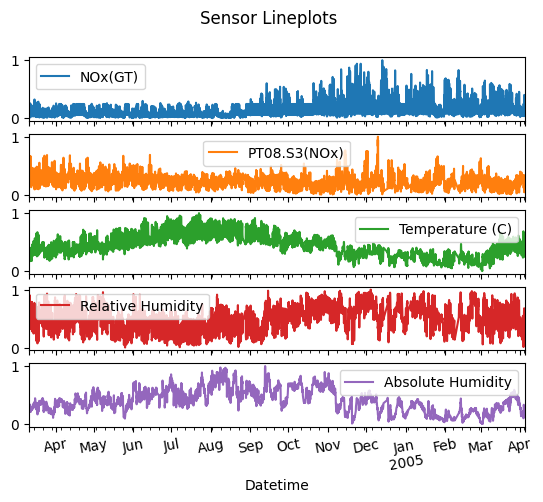

In [ ]:
nox.plot("Datetime", columns_of_interest, subplots=True)
plt.suptitle("Sensor Lineplots")
plt.xticks(rotation=10)
plt.show()


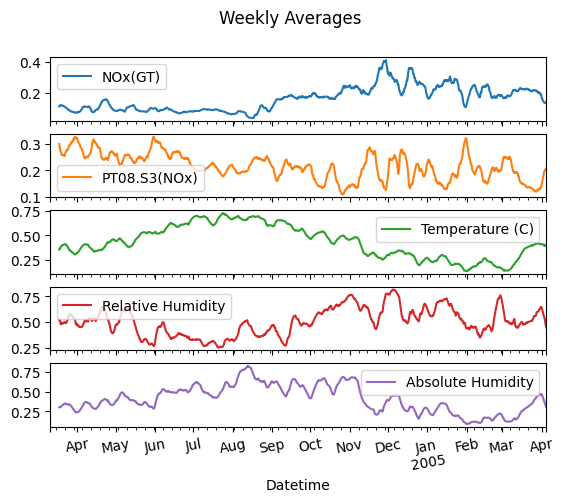

In [ ]:
weekly_average = nox.copy()
weekly_average[columns_of_interest] = nox[columns_of_interest].rolling(7 * 24).mean()
#get trends long term
weekly_average.plot("Datetime", columns_of_interest, subplots=True)
plt.suptitle("Weekly Averages")
plt.xticks(rotation=10)
plt.show()


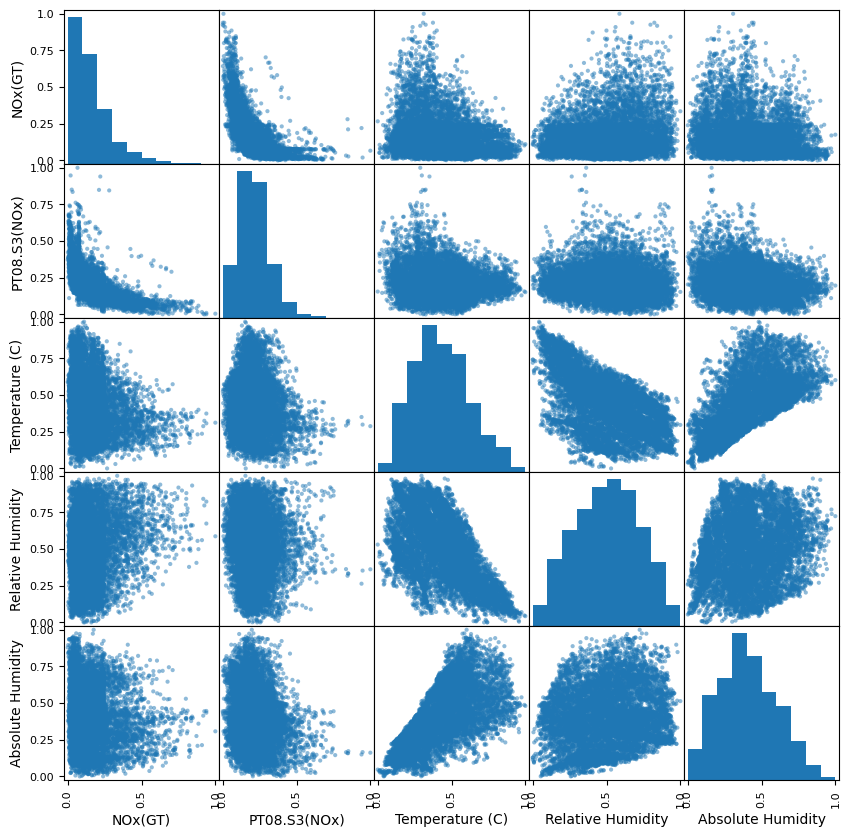

In [ ]:
axes = pd.plotting.scatter_matrix(
    nox[columns_of_interest],
    alpha=0.5,
    figsize=[10, 10]
)
plt.show()


In [ ]:
corr = nox[columns_of_interest].corr(method="spearman")
corr


,NOx(GT),PT08.S3(NOx),Temperature (C),Relative Humidity,Absolute Humidity
NOx(GT),1.000000,-0.746382,-0.213114,0.117813,-0.157407
PT08.S3(NOx),-0.746382,1.000000,-0.092953,-0.092665,-0.192637
Temperature (C),-0.213114,-0.092953,1.000000,-0.536289,0.704901
Relative Humidity,0.117813,-0.092665,-0.536289,1.000000,0.157820
Absolute Humidity,-0.157407,-0.192637,0.704901,0.157820,1.000000


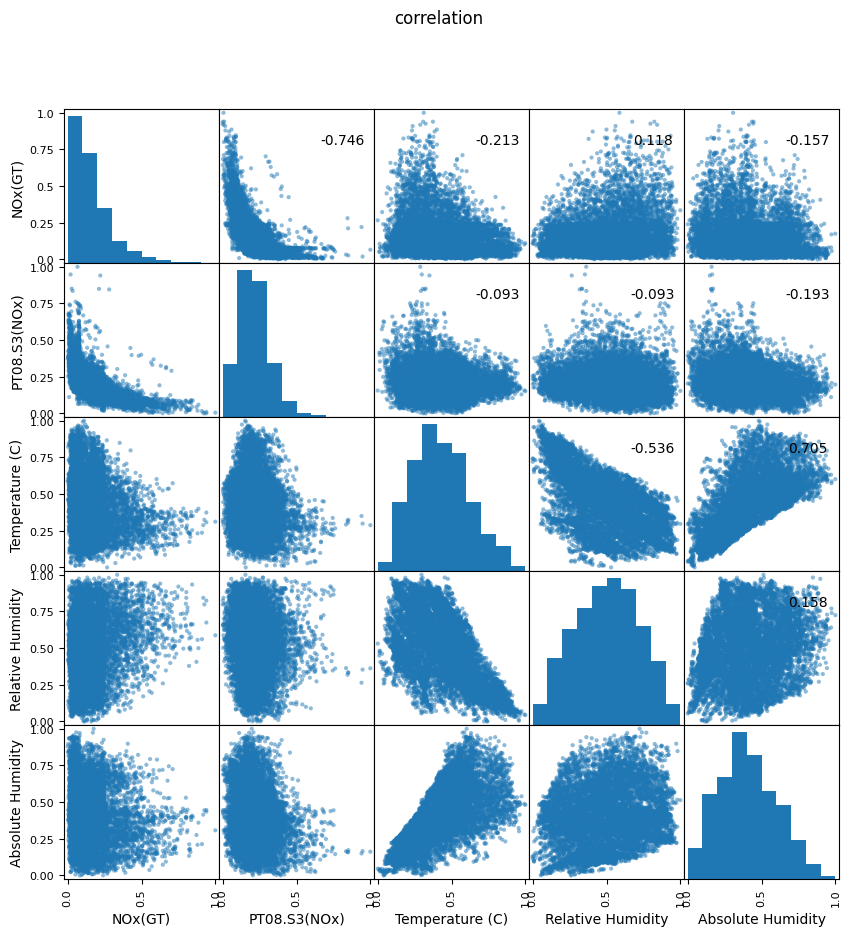

In [ ]:
axes = pd.plotting.scatter_matrix(
    nox[columns_of_interest],
    alpha=0.5,
    figsize=[10, 10]
)

corr_vals = corr.to_numpy()

for i, j in zip(*plt.np.triu_indices_from(corr_vals, k=1)):
    axes[i, j].annotate(
        "%.3f" % corr_vals[i, j],
        (0.8, 0.8),
        xycoords="axes fraction",
        ha="center",
        va="center"
    )

plt.suptitle("correlation")
plt.show()
